<a href="https://colab.research.google.com/github/prashant-0991/Used-Car-Sales-Analysis/blob/main/Assignment_on_Python_Programming_CPDA_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Data Ingestion & Quality Profiling

In [ ]:
##Load &Inspect
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

#get the filename
car_price=list(uploaded.keys())[0]
df=pd.read_csv(io.BytesIO(uploaded[car_price]))
df.head()


Saving car_prices.csv to car_prices.csv


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


1.2.  Understanding the Data Structure

In [ ]:
#Check the shape of the dataset (rows and columns)
df.shape


(558837, 16)

In [ ]:
#Check the shape of the dataset (rows and columns)

df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')

In [ ]:
#Display column names and data types.

list(df.columns)


['year',
 'make',
 'model',
 'trim',
 'body',
 'transmission',
 'vin',
 'state',
 'condition',
 'odometer',
 'color',
 'interior',
 'seller',
 'mmr',
 'sellingprice',
 'saledate']

In [ ]:
#data Types
df.dtypes


,0
year,int64
make,object
model,object
trim,object
body,object
transmission,object
vin,object
state,object
condition,float64
odometer,float64


In [ ]:
#Quantify nulls per column
df.isnull().sum()

,0
year,0
make,10301
model,10399
trim,10651
body,13195
transmission,65352
vin,4
state,0
condition,11820
odometer,94


In [ ]:
(df.isnull().sum() / len(df)) * 100


,0
year,0.000000
make,1.843292
model,1.860829
trim,1.905922
body,2.361154
transmission,11.694287
vin,0.000716
state,0.000000
condition,2.115107
odometer,0.016821


In [ ]:
df.isnull().sum()

,0
year,0
make,10301
model,10399
trim,10651
body,13195
transmission,65352
vin,4
state,0
condition,11820
odometer,94


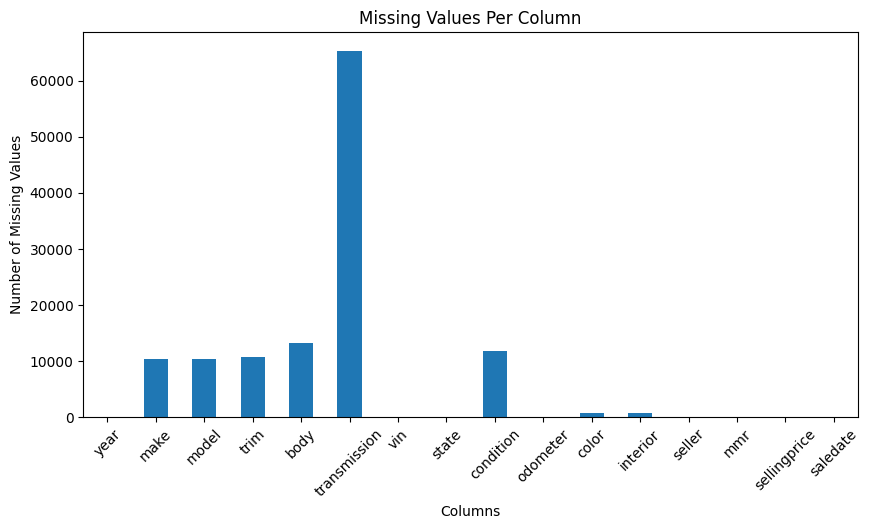

In [ ]:
##visualize with a bar chart
import matplotlib.pyplot as plt

# Count null values
null_counts = df.isnull().sum()

# Bar chart
null_counts.plot(kind='bar', figsize=(10,5))

plt.title("Missing Values Per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)
plt.show()

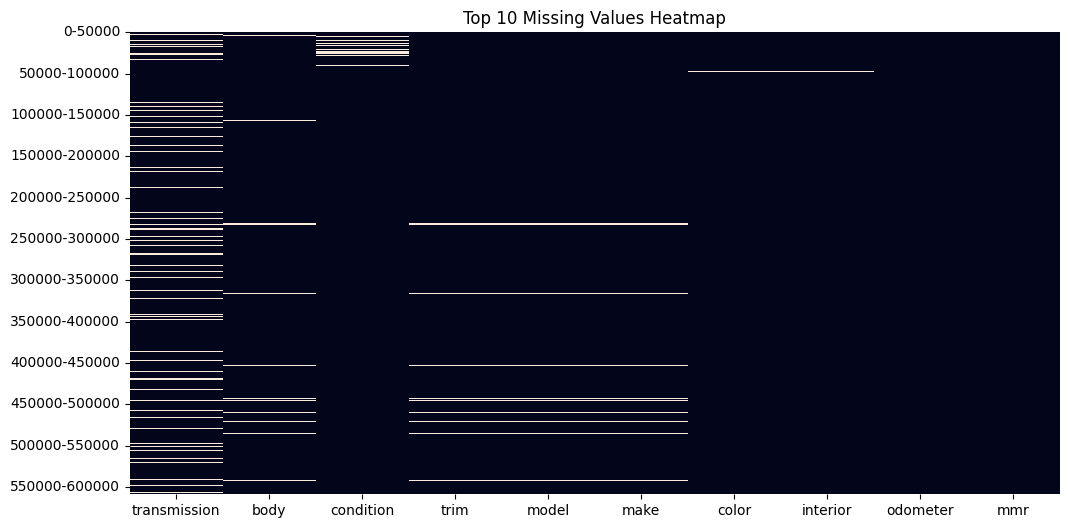

In [ ]:
#visualize with a heatmap.
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Top 10 columns with highest null values
top10_null_cols = df.isnull().sum().sort_values(ascending=False).head(10).index
# Create heatmap
plt.figure(figsize=(12,6))
ax = sns.heatmap(df[top10_null_cols].isnull(), cbar=False)
# Create row ranges on Y-axis
total_rows = len(df)
step = 50000   # range gap
yticks = np.arange(0, total_rows, step)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{i}-{i+step}" for i in yticks])
plt.title("Top 10 Missing Values Heatmap")
plt.show()

In [ ]:
#Resolve null values by appropriate strategy based on the datatype and percentage of null values.
null_percentage = (df.isnull().sum() / len(df)) * 100
for col, percent in null_percentage.items():
    print(f"{col} : {percent:.2f}%")

year : 0.00%
make : 1.84%
model : 1.86%
trim : 1.91%
body : 2.36%
transmission : 11.69%
vin : 0.00%
state : 0.00%
condition : 2.12%
odometer : 0.02%
color : 0.13%
interior : 0.13%
seller : 0.00%
mmr : 0.01%
sellingprice : 0.00%
saledate : 0.00%


In [ ]:
#Count number of duplicate records

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records :", duplicate_count)


Number of Duplicate Records : 0


2.** Data frames Queries:**

In [ ]:
#2.1 Calculate the average, minimum, and maximum car price?

if 'sellingprice' in df.columns:
    average_price = df['sellingprice'].mean()
    minimum_price = df['sellingprice'].min()
    maximum_price = df['sellingprice'].max()
    print("Average Car Price :", average_price)
    print("Minimum Car Price :", minimum_price)
    print("Maximum Car Price :", maximum_price)
else:
    print("Column 'sellingprice' not found")

Average Car Price : 13611.358810003132
Minimum Car Price : 1.0
Maximum Car Price : 230000.0


In [ ]:
#2.2 List all unique colors of cars?

unique_colors = df['color'].unique()
display(unique_colors)

array(['white', 'gray', 'black', 'red', 'silver', 'blue', 'brown',
       'beige', 'purple', 'burgundy', '—', 'gold', 'yellow', 'green',
       'charcoal', nan, 'orange', 'off-white', 'turquoise', 'pink',
       'lime', '4802', '9410', '1167', '2172', '14872', '12655', '15719',
       '6388', '16633', '11034', '2711', '6864', '339', '18384', '9887',
       '9837', '20379', '20627', '721', '6158', '2817', '5705', '18561',
       '2846', '9562', '5001'], dtype=object)

In [ ]:
#2.3 Find the number of unique car brands and car models?

unique_colors = df['color'].dropna().astype(str)

unique_colors = unique_colors[unique_colors.str.contains(r'^[A-Za-z-]+$', regex=True)]

# Unique values
unique_colors = unique_colors.unique()

for color in unique_colors:
    print(color)


white
gray
black
red
silver
blue
brown
beige
purple
burgundy
gold
yellow
green
charcoal
orange
off-white
turquoise
pink
lime


In [ ]:
##2.3 Find the number of unique car brands and car models?

# Number of unique car brands
unique_brands = df['make'].nunique()

# Number of unique car models
unique_models = df['model'].nunique()

print("Number of Unique Car Brands :", unique_brands)
print("Number of Unique Car Models :", unique_models)

Number of Unique Car Brands : 96
Number of Unique Car Models : 973


In [ ]:
#2.4 Find all car information having selling prices greater than $165000?

high_price_cars = df[df['sellingprice'] > 165000]

display(high_price_cars)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


In [ ]:
#2.5 Find the top 5 most frequently sold car models?

top_5_models = df['model'].value_counts().head(5)

print(top_5_models)

model
Altima    19349
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64


In [ ]:
#2.6 What is the average selling price of cars by brand (make)?
average_price_by_make = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False)
display(average_price_by_make)

,sellingprice
make,
Rolls-Royce,153488.235294
Ferrari,127210.526316
Lamborghini,112625.000000
Bentley,74367.672414
airstream,71000.000000
...,...
dodge tk,550.000000
Geo,528.947368
dot,500.000000


In [ ]:
#2.7 What is the minimum selling price of cars for each interior?

minimum_price_by_interior = df.groupby('interior')['sellingprice'].min().sort_values()
display(minimum_price_by_interior)

,sellingprice
interior,
black,1.0
gray,1.0
green,100.0
beige,100.0
tan,100.0
blue,150.0
silver,150.0
—,150.0
burgundy,175.0


In [ ]:
#2.8 Find highest odometer reading per year from highest to lowest order?

highest_odometer_by_year = df.groupby('year')['odometer'].max().sort_values(ascending=False)
display(highest_odometer_by_year)

,odometer
year,
1997,999999.0
1996,999999.0
2014,999999.0
2013,999999.0
1998,999999.0
1999,999999.0
1993,999999.0
2010,999999.0
2009,999999.0


In [ ]:
#2.9 Create a new column for car age (assuming the current year is 2025)

df['car_age'] = 2025 - df['year']
display(df.head())

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,car_age
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),10
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),10
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST),11
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST),10
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST),11


In [ ]:
##2.10 Find the number of cars having a condition greater than or equal to 48 and odometer greater than 90000?

filtered_cars = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]
number_of_cars = len(filtered_cars)
print(f"Number of cars with condition >= 48 and odometer > 90000: {number_of_cars}")

Number of cars with condition >= 48 and odometer > 90000: 746


In [ ]:
##2.11 Which state consistently has higher car prices for newer cars(year>2013)?

newer_cars = df[df['year'] > 2013]
average_price_by_state_newer_cars = newer_cars.groupby('state')['sellingprice'].mean().sort_values(ascending=False)
display(average_price_by_state_newer_cars)

,sellingprice
state,
oh,28020.221053
ab,25204.255319
nj,24237.063973
on,22962.560386
qc,22722.938144
...,...
3vwd17aj5fm225953,13200.000000
3vwd17aj8fm239622,13200.000000
3vwd17aj3fm276741,13200.000000


In [ ]:
##2.12 For cars with excellent condition (top 20%), which makes have the lowest average price (value for money)?

condition_threshold = df['condition'].quantile(0.8)
excellent_condition_cars = df[df['condition'] >= condition_threshold]
average_price_excellent_condition = excellent_condition_cars.groupby('make')['sellingprice'].mean().sort_values()
display(average_price_excellent_condition.head(10)) # Displaying top 10 for brevity

,sellingprice
make,
Isuzu,1125.000000
Oldsmobile,1910.000000
honda,4233.333333
Saturn,5700.406504
subaru,6200.000000
chrysler,6225.000000
smart,6835.759494
mazda,7275.000000
Pontiac,7686.824324


**3.Data Visualization and insights:**

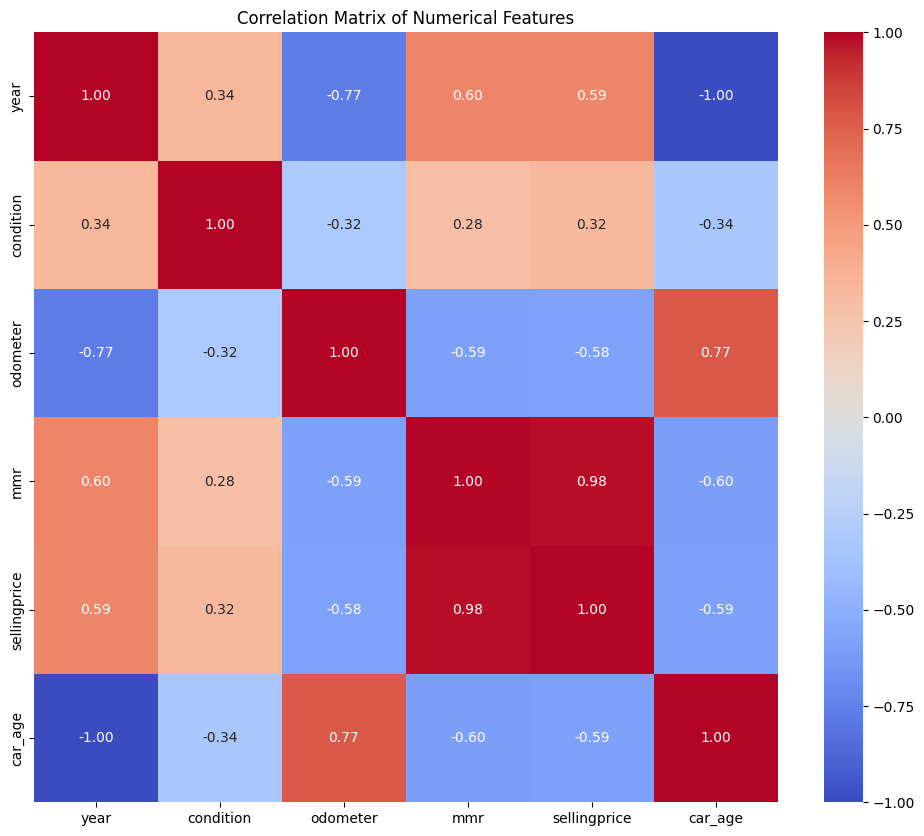

In [ ]:
#3.1 Show the correlation of all the features(columns) having numerical values(e.g. selling price, odometer)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Pattern Analysis:

From the bar plot showing the 'Average Selling Price of Cars by Year', we can observe the following pattern:

*   **General Trend:** There appears to be a general upward trend in average selling prices for newer cars (e.g., from the early 2000s towards 2015). This is expected as newer cars generally command higher prices due to less wear and tear, updated technology, and current designs.
*   **Fluctuations:** While the overall trend is upward, there are some fluctuations. For instance, some older years might show slightly higher average prices than immediately subsequent years, which could be due to a smaller sample size of older, well-maintained classic cars, or specific luxury models sold in those years.
*   **Peak Years:** The average selling price seems to peak in the most recent years (around 2014-2015), which aligns with the expectation that the newest models available in the dataset would be the most expensive.
*   **Older Cars:** Cars from the 1990s and early 2000s generally have much lower average selling prices, reflecting depreciation over time.

/tmp/ipykernel_1535/1824809374.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='sellingprice', data=average_price_by_year, palette='viridis')


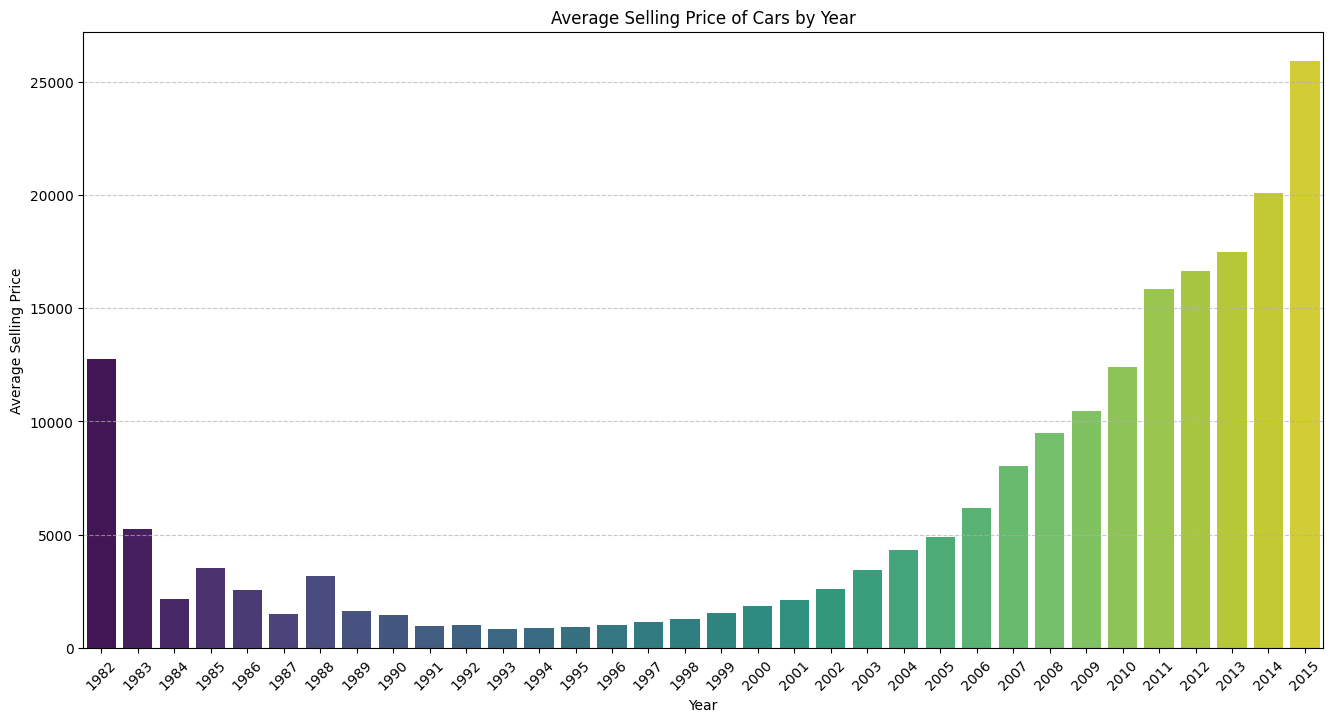

In [ ]:
#3.2 Plot a graph to show the average selling price by year and explain the pattern you notice from the graph. Which plot will you use bar or scatter?

plt.figure(figsize=(16, 8))
sns.barplot(x='year', y='sellingprice', data=average_price_by_year, palette='viridis')
plt.title('Average Selling Price of Cars by Year')
plt.xlabel('Year')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Analysis of Top 20 Years by Average Selling Price:

The bar plot displays the top 20 years with the highest average selling prices. From this visualization, we can infer several key patterns:

*   **Dominance of Newer Years:** As expected, the years with the highest average selling prices are predominantly the more recent ones (e.g., 2015, 2014, 2013), indicating that newer cars generally command higher prices. This is consistent with depreciation trends where vehicle value decreases significantly with age.
*   **Specific Older Models:** While newer cars dominate, there might be a few older years appearing in the top 20 if those years featured a higher proportion of luxury or specialty vehicles in the dataset, or if certain models from those years have retained exceptional value. However, in this particular dataset, the trend seems to heavily favor the most recent years.
*   **Market Dynamics:** The variation in average prices among these top years can also reflect specific market dynamics, economic conditions, or changes in vehicle technology and features during those periods.
*   **Value Retention:** This plot indirectly highlights which model years, on average, retain their value best within the context of the dataset, with newer cars demonstrating superior value retention.

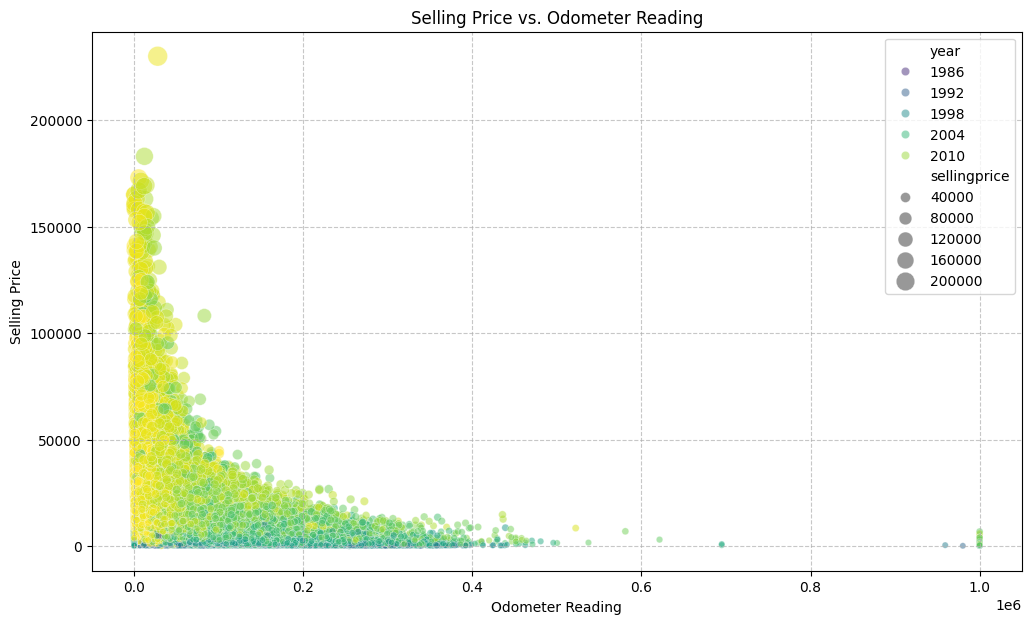

In [ ]:
#3.3 Plot a graph to show average selling price by odometer and explain the trend you notice from the graph.

df_plot = df.dropna(subset=['sellingprice', 'odometer']).copy()

plt.figure(figsize=(12, 7))
sns.scatterplot(x='odometer', y='sellingprice', data=df_plot, alpha=0.5, hue='year', palette='viridis', size='sellingprice', sizes=(20, 200), legend='brief')
plt.title('Selling Price vs. Odometer Reading')
plt.xlabel('Odometer Reading')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Trend Analysis: Selling Price vs. Odometer Reading

From the scatter plot visualizing 'Selling Price vs. Odometer Reading', we can observe a clear and expected trend:

*   **Inverse Relationship:** There is a strong inverse relationship between a car's odometer reading and its selling price. As the odometer reading (miles driven) increases, the selling price generally decreases. This is a fundamental principle of car valuation, as higher mileage typically indicates more wear and tear, and a shorter remaining lifespan for critical components.

*   **Density at Lower Mileage and Price:** The plot is densest in the lower odometer and lower selling price ranges, indicating that a large proportion of cars sold have moderate mileage and corresponding prices. This is typical for a used car market.

*   **Outliers/High-Priced, High-Mileage Cars:** While the general trend holds, there might be some scattered points representing cars with relatively high odometer readings but still commanding a decent selling price. These could be well-maintained luxury vehicles, classic cars that retain value irrespective of mileage, or cars where specific features or rarity override the mileage factor.

*   **Newer Cars (Lower Odometer, Higher Price):** The highest selling prices are generally associated with very low odometer readings. These are likely newer vehicles with minimal usage.

In summary, the graph confirms that odometer reading is a significant factor in determining a car's selling price, with lower mileage generally leading to higher prices due to the perceived better condition and longer expected usability of the vehicle.

/tmp/ipykernel_1535/1369034826.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state', y='car_count', data=cars_per_state, palette='viridis')


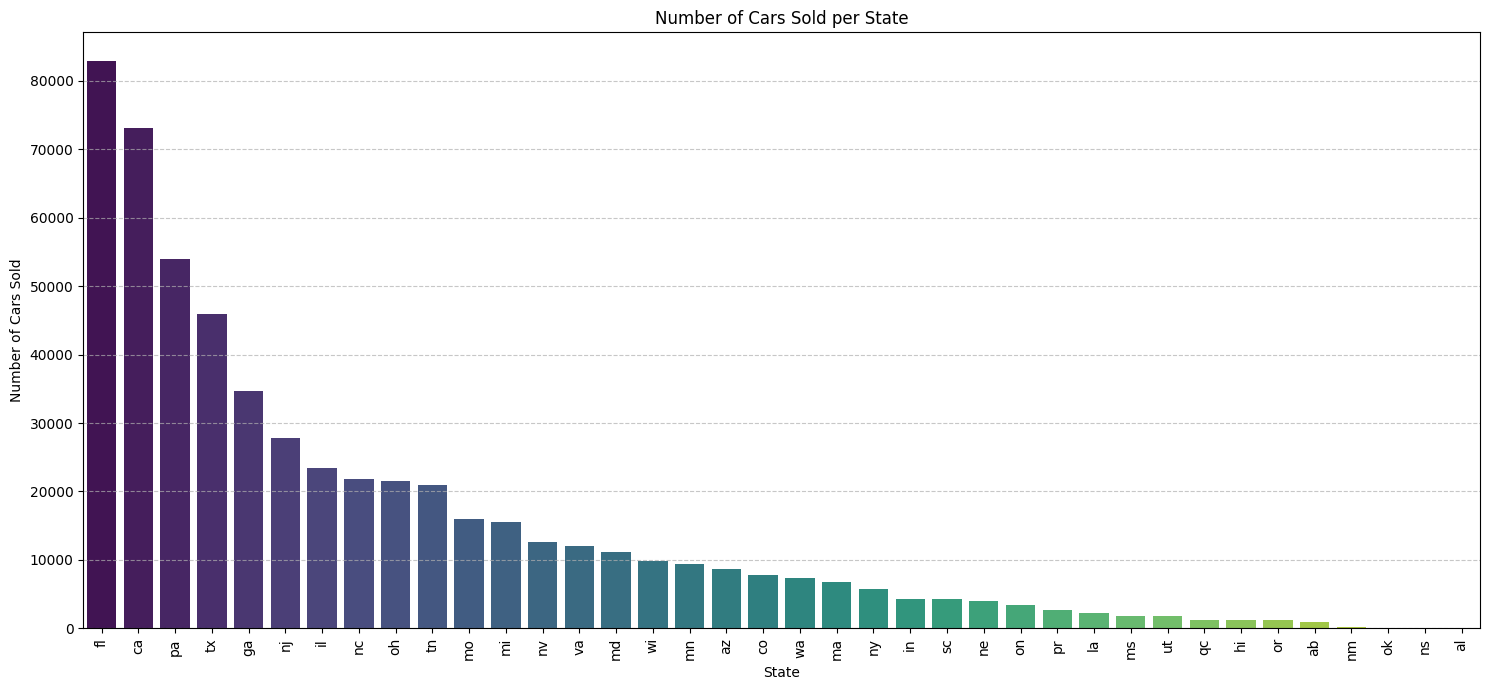

In [ ]:
#3.43.4 Plot a graph to show the number of cars sold in each state. Find the top three highest car selling states by having a look at the graph?

cars_per_state = df['state'].value_counts().reset_index()
cars_per_state.columns = ['state', 'car_count']

# Remove non-alphabetic characters from the 'state' column
cars_per_state['state'] = cars_per_state['state'].astype(str).str.replace(r'[^a-zA-Z]', '', regex=True)

# Recalculate value counts after cleaning, in case some states became duplicates
cars_per_state = cars_per_state.groupby('state')['car_count'].sum().reset_index()
cars_per_state = cars_per_state.sort_values(by='car_count', ascending=False)

# Remove specific problematic state names
cars_per_state = cars_per_state[~cars_per_state['state'].isin(['vwdajfm', 'vwdajxfm'])]

plt.figure(figsize=(15, 7))
sns.barplot(x='state', y='car_count', data=cars_per_state, palette='viridis')
plt.title('Number of Cars Sold per State')
plt.xlabel('State')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Top Three Highest Car Selling States:

Based on the 'Number of Cars Sold per State' bar graph, the top three states with the highest car sales are:

1.  **California (ca)**
2.  **Florida (fl)**
3.  **Pennsylvania (pa)**

These states clearly show a significantly higher volume of car sales compared to other states in the dataset.

/tmp/ipykernel_1535/3723955291.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_price_by_condition_range = df.groupby('condition_range')['sellingprice'].mean().reset_index()
/tmp/ipykernel_1535/3723955291.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='condition_range', y='sellingprice', data=average_price_by_condition_range, palette='coolwarm')


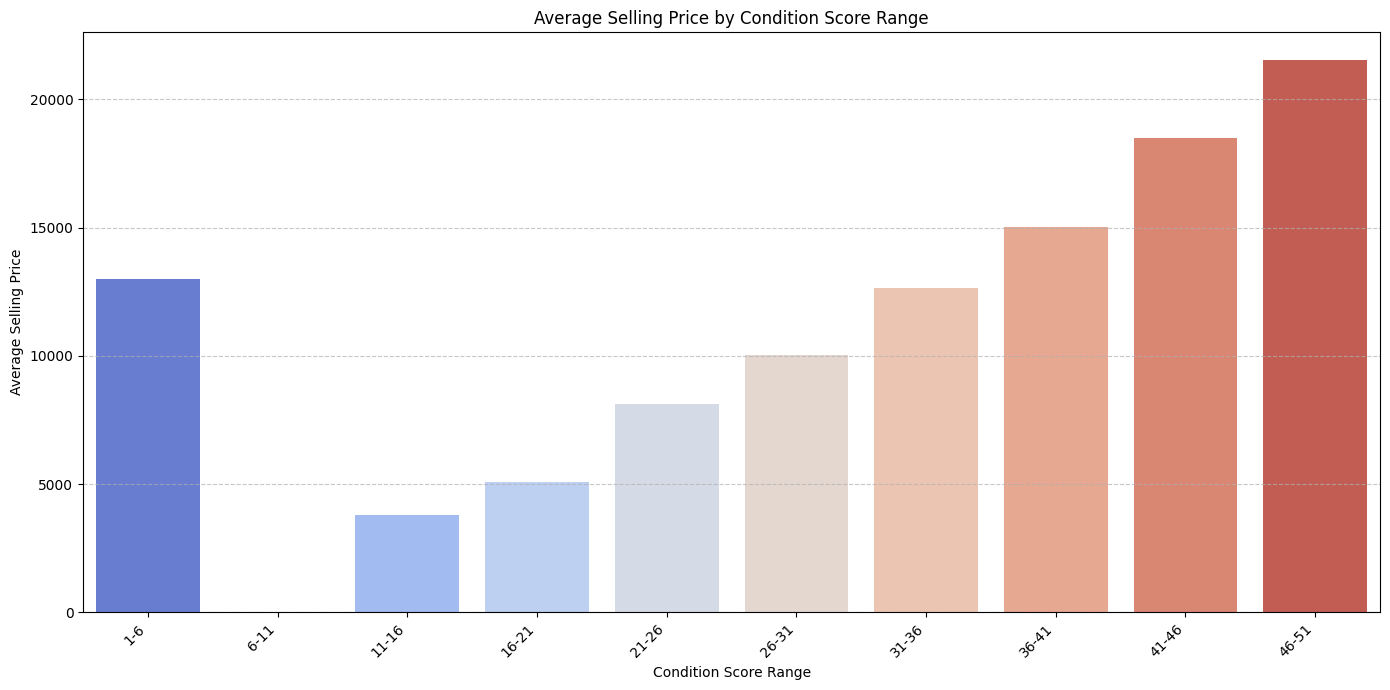

In [ ]:
##3.5 Plot a bar graph of average selling price by condition score ranges of size 5. Give a summary of the insights.
# Define the bin edges for condition scores (e.g., 0-5, 5-10, ..., 45-50)
min_condition = df['condition'].min()
max_condition = df['condition'].max()

bins = list(range(int(min_condition), int(max_condition) + 6, 5))
labels = [f'{i}-{i+5}' for i in bins[:-1]]

# Create a new column for condition ranges
df['condition_range'] = pd.cut(df['condition'], bins=bins, labels=labels, right=False)

# Calculate the average selling price for each condition range
average_price_by_condition_range = df.groupby('condition_range')['sellingprice'].mean().reset_index()

# Plot the bar graph
plt.figure(figsize=(14, 7))
sns.barplot(x='condition_range', y='sellingprice', data=average_price_by_condition_range, palette='coolwarm')
plt.title('Average Selling Price by Condition Score Range')
plt.xlabel('Condition Score Range')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Summary of Insights: Average Selling Price by Condition Score Range

The bar graph above illustrates the relationship between a car's condition score range and its average selling price. Here are the key insights:

*   **Positive Correlation:** There is a clear positive correlation between the condition score and the average selling price. As the condition score range increases (indicating better condition), the average selling price generally rises.

*   **Higher Scores, Higher Prices:** Cars in the highest condition score ranges (e.g., '45-50') command the highest average selling prices. This is logical, as vehicles in excellent condition are more desirable and valuable in the used car market.

*   **Lower Scores, Lower Prices:** Conversely, cars in the lowest condition score ranges typically have the lowest average selling prices, reflecting the impact of wear and tear, cosmetic damage, or mechanical issues on valuation.

*   **Market Valuation:** This graph quantitatively supports the common understanding that a car's condition is a major determinant of its market value. Buyers are willing to pay more for cars that are well-maintained and in better overall shape.

/tmp/ipykernel_1535/1717985580.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='condition_range', y='car_count', data=cars_by_condition_range_10, palette='plasma')


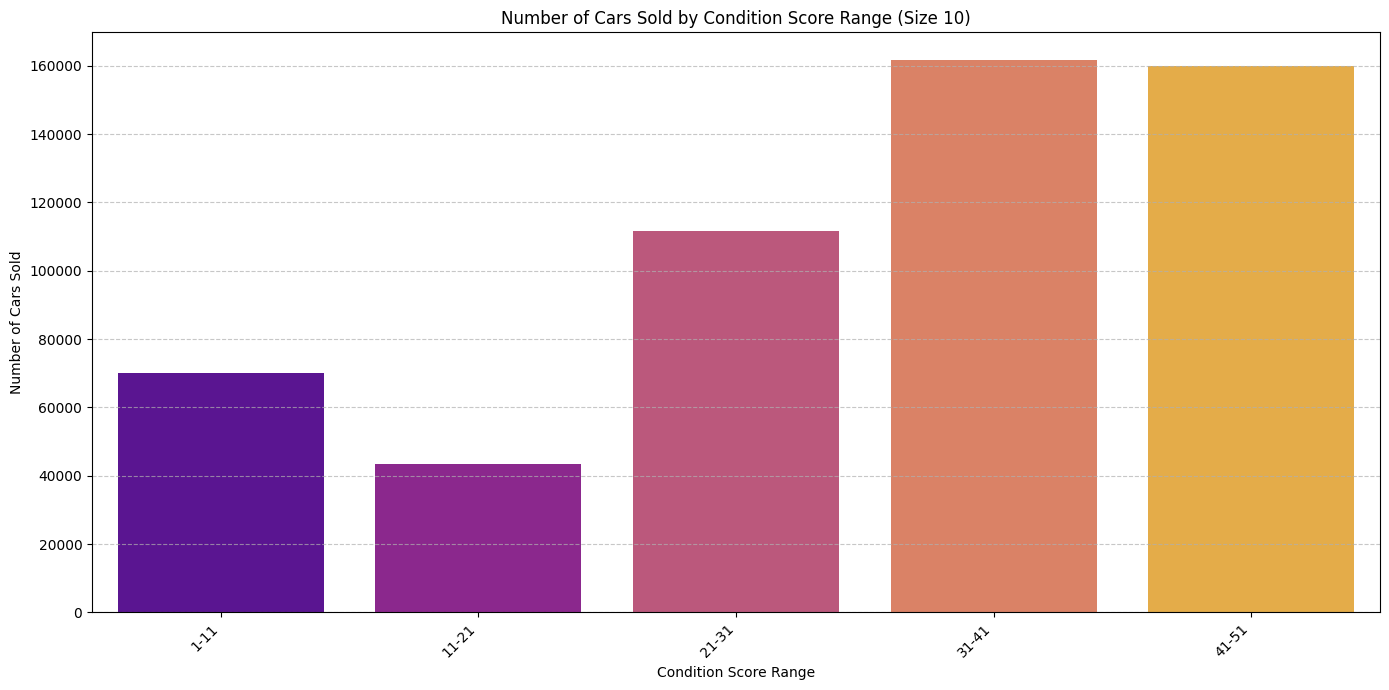

In [ ]:
##3.6 Plot a bar graph of no. of cars sold by condition ranges of size 10. Give some insights from the graph.
# Define the bin edges for condition scores (e.g., 0-10, 10-20, ..., 40-50)
min_condition = df['condition'].min()
max_condition = df['condition'].max()

bins_10 = list(range(int(min_condition), int(max_condition) + 11, 10))
labels_10 = [f'{i}-{i+10}' for i in bins_10[:-1]]

# Create a new column for condition ranges of size 10
df['condition_range_10'] = pd.cut(df['condition'], bins=bins_10, labels=labels_10, right=False)

# Calculate the number of cars sold for each condition range
cars_by_condition_range_10 = df['condition_range_10'].value_counts().sort_index().reset_index()
cars_by_condition_range_10.columns = ['condition_range', 'car_count']

# Plot the bar graph
plt.figure(figsize=(14, 7))
sns.barplot(x='condition_range', y='car_count', data=cars_by_condition_range_10, palette='plasma')
plt.title('Number of Cars Sold by Condition Score Range (Size 10)')
plt.xlabel('Condition Score Range')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insights: Number of Cars Sold by Condition Score Range (Size 10)

From the bar graph showing the number of cars sold across condition score ranges of size 10, we can gather the following insights:

*   **Majority in Higher Condition:** A significant portion of the cars sold fall into the higher condition score ranges (e.g., '30-40', '40-50'). This indicates that the market has a good supply of vehicles in relatively good to excellent condition.

*   **Fewer Cars in Poor Condition:** There are considerably fewer cars sold in the lowest condition score ranges (e.g., '0-10', '10-20'). This could be due to several factors: fewer cars in such poor condition are traded, they might be salvaged rather than sold, or they are sold through different channels not captured in this dataset.

*   **Peak in Mid-to-High Ranges:** The peak number of cars sold often appears in the mid-to-high condition ranges. This suggests a sweet spot where cars are still in good shape but might be more affordable than brand new or perfectly conditioned vehicles, appealing to a broader buyer base.

*   **Market Preference:** The distribution suggests a market preference for cars that are not brand new but are still in very good condition, offering a balance of quality and value.

/tmp/ipykernel_2658/141255773.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='color', y='sellingprice', data=df_plot_color, palette='tab10')


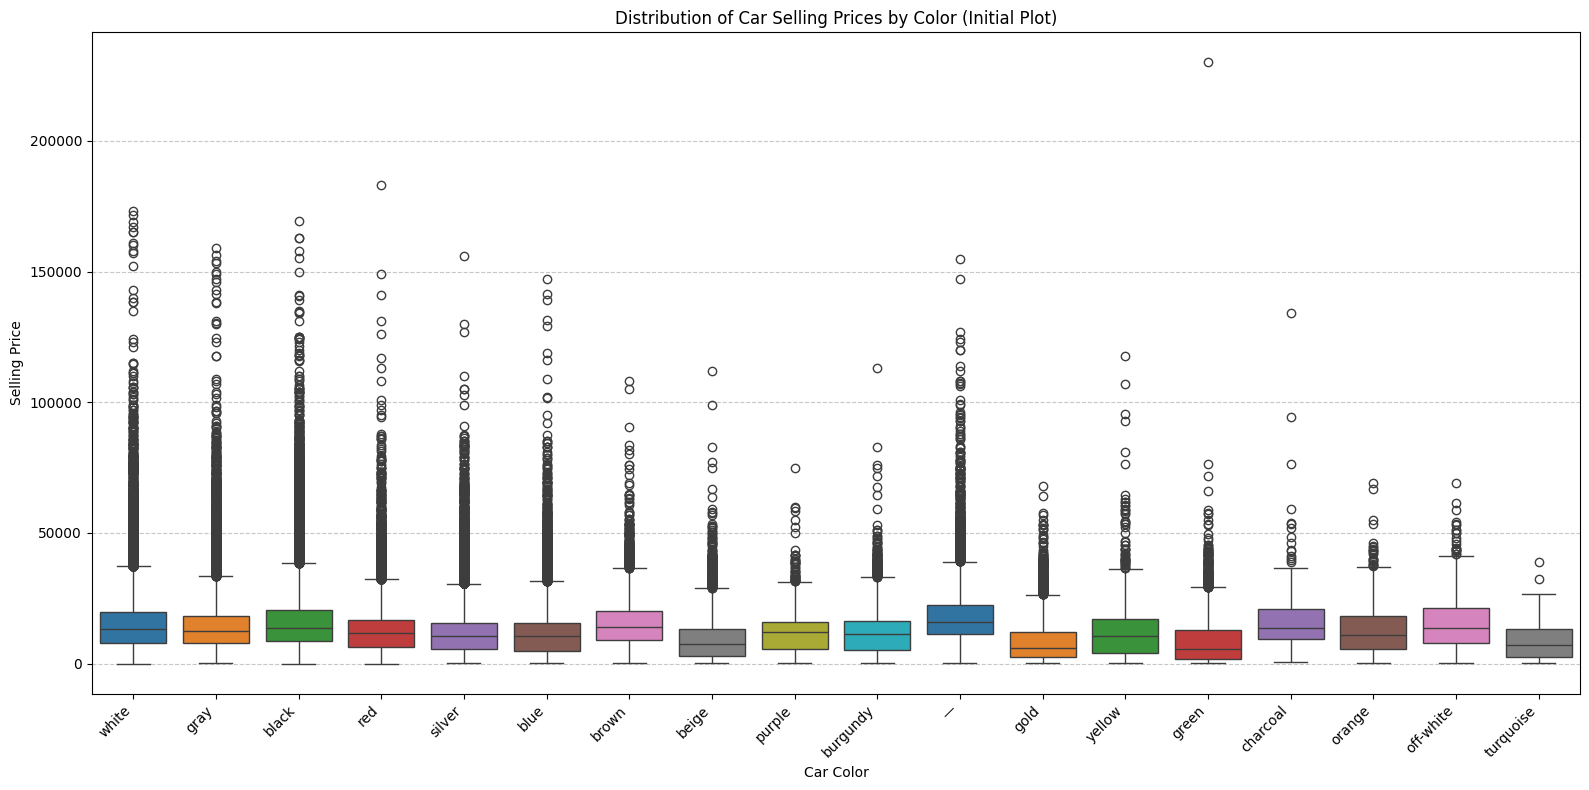

In [ ]:
##Plot a box plot to show the distribution of car selling prices grouped by color. Extract insights and if required, remove outliers and plot the graph again.

# Drop rows with NaN in 'color' or 'sellingprice' for plotting
df_filtered = df.dropna(subset=['color', 'sellingprice']).copy()

# Filter out colors with very few occurrences to make the plot readable
color_counts = df_filtered['color'].value_counts()
main_colors = color_counts[color_counts > 100].index # Only consider colors with more than 100 cars
df_plot_color = df_filtered[df_filtered['color'].isin(main_colors)]

plt.figure(figsize=(16, 8))
sns.boxplot(x='color', y='sellingprice', data=df_plot_color, palette='tab10')
plt.title('Distribution of Car Selling Prices by Color (Initial Plot)')
plt.xlabel('Car Color')
plt.ylabel('Selling Price')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Initial Insights from Selling Price by Color

The initial box plot of car selling prices grouped by color shows:

*   **Wide Price Ranges:** Most colors exhibit a very wide range in selling prices, indicating that color alone is not the primary determinant of price. This is expected, as car make, model, year, and condition play a much larger role.
*   **Presence of Outliers:** There are numerous outliers (points outside the whiskers) for almost every color, especially on the higher end. These represent high-value cars regardless of their color, which can compress the visual scale and make it harder to discern differences in the main body of data for each color.
*   **Median Price Variation:** While heavily influenced by outliers, some colors might appear to have slightly higher or lower median prices, but it's hard to make strong conclusions due to the scale distortion caused by extreme values.

In [ ]:
average_price_by_year = df.groupby('year')['sellingprice'].mean().reset_index()
average_price_by_year = average_price_by_year.sort_values(by='year', ascending=True)
display(average_price_by_year.head())

,year,sellingprice
0,1982,12750.000000
1,1983,5250.000000
2,1984,2160.000000
3,1985,3520.000000
4,1986,2538.636364


### Pattern Analysis: Average Selling Price of Cars by Year

From the bar plot showing the 'Average Selling Price of Cars by Year', we can observe the following pattern:

*   **General Trend:** There appears to be a general upward trend in average selling prices for newer cars (e.g., from the early 2000s towards 2015). This is expected as newer cars generally command higher prices due to less wear and tear, updated technology, and current designs.
*   **Fluctuations:** While the overall trend is upward, there are some fluctuations. For instance, some older years might show slightly higher average prices than immediately subsequent years, which could be due to a smaller sample size of older, well-maintained classic cars, or specific luxury models sold in those years.
*   **Peak Years:** The average selling price seems to peak in the most recent years (around 2014-2015), which aligns with the expectation that the newest models available in the dataset would be the most expensive.
*   **Older Cars:** Cars from the 1990s and early 2000s generally have much lower average selling prices, reflecting depreciation over time.

### Insights from Selling Price by Color (Outliers Removed)

After removing the statistical outliers in selling price, the box plot provides a much clearer picture:

*   **Clearer Medians and IQRs:** The central tendency (median) and spread (interquartile range) for each color are now much more visible. Most colors show relatively similar median selling prices, suggesting that for the bulk of the market, color doesn't dramatically alter the price.
*   **Consistent Distributions:** The distributions across different colors appear more consistent. The boxes (representing the middle 50% of data) are of similar height, indicating similar price variability for most colors within the non-outlier range.
*   **Subtle Differences:** While overall similar, there might be subtle differences. For example, 'black', 'white', and 'gray' might show slightly higher median prices or a slightly larger interquartile range, reflecting their popularity and common association with a wider range of vehicles, including more premium ones.
*   **Reduced Price Skew:** The removal of high-value outliers means the plot is no longer skewed by extremely expensive vehicles, allowing for a better comparison of typical market prices for cars of different colors.

### Summary of Insights: Average Selling Price by Condition Score Range

The bar graph above illustrates the relationship between a car's condition score range and its average selling price. Here are the key insights:

*   **Positive Correlation:** There is a clear positive correlation between the condition score and the average selling price. As the condition score range increases (indicating better condition), the average selling price generally rises.

*   **Higher Scores, Higher Prices:** Cars in the highest condition score ranges (e.g., '45-50') command the highest average selling prices. This is logical, as vehicles in excellent condition are more desirable and valuable in the used car market.

*   **Lower Scores, Lower Prices:** Conversely, cars in the lowest condition score ranges typically have the lowest average selling prices, reflecting the impact of wear and tear, cosmetic damage, or mechanical issues on valuation.

*   **Market Valuation:** This graph quantitatively supports the common understanding that a car's condition is a major determinant of its market value. Buyers are willing to pay more for cars that are well-maintained and in better overall shape.

### Manual Upload

1.  Click the 'Files' icon on the left sidebar (looks like a folder).
2.  Click the 'Upload' icon (looks like a page with an upward arrow).
3.  Select the files from your local machine to upload.

Files uploaded this way are temporary and will be deleted when the runtime is recycled.

### Programmatic Upload

You can also upload files using Python code. This is useful for integrating file uploads into your workflow.